# DSBA6010 Final Project - V2
## LLM-Based Privacy Attacks on Census Income Data

**Dataset:** [Adult (Census Income) Dataset - UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/2/adult)  
**Project Overview:**  
This notebook investigates the privacy risks of sharing census income data in the age of Large Language Models (LLMs). We:
1. Load and explore the Adult Census Income dataset
2. Predict whether income **exceeds $50K/year** (binary classification)
3. Apply Differential Privacy (DP) at multiple epsilon levels
4. Assess utility (model accuracy) after privatization
5. Attack the privatized dataset using Membership Inference and Attribute Inference attacks

**Dataset Description:**  
Extraction from the 1994 Census database. The prediction task is to determine whether a person makes over $50K a year based on census attributes including age, education, occupation, work hours, and demographic information.

**Original Citation:**
Becker, Barry and Kohavi, Ronny. (1996). Adult. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20.

**References:**
- Liu et al. (2025) — Evaluating LLM-based Personal Information Extraction and Countermeasures. USENIX Security.
- Staab et al. (2024) — Beyond Memorization: Violating Privacy via Inference with LLMs. ICLR.
- Jayaraman & Evans (2022) — Are Attribute Inference Attacks Just Imputation? CCS.
- Kandpal et al. (2024) — User Inference Attacks on Large Language Models. EMNLP.

## 0. Install Dependencies

In [1]:
# Run this cell once to install required packages
!pip install pandas numpy matplotlib seaborn scikit-learn diffprivlib kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 9.9 MB/s eta 0:00:00


## 1. Setup & Data Loading

**Data Source:** [UCI Machine Learning Repository - Adult Dataset](https://archive.ics.uci.edu/dataset/2/adult)

The dataset contains census data extracted from the 1994 Census database. The prediction task is to determine whether a person makes over $50K a year.

**Key Features:**
- **Demographic**: age, sex, race, native-country
- **Work-related**: workclass, occupation, hours-per-week
- **Education**: education level, education-num
- **Family**: marital-status, relationship
- **Financial**: capital-gain, capital-loss

**Target**: Income level (<=50K or >50K)

In [ ]:
import pandas as pd

# Column names for the Adult dataset
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
test_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

print("Loading dataset from UCI repository...")

# Load and combine train/test data
df_train = pd.read_csv(train_url, names=column_names, sep=r'\s*,\s*', 
                       engine='python', na_values='?', skipinitialspace=True)
df_test = pd.read_csv(test_url, names=column_names, sep=r'\s*,\s*', 
                      engine='python', na_values='?', skipinitialspace=True, skiprows=1)
df = pd.concat([df_train, df_test], ignore_index=True)

# Clean income column
df['income'] = df['income'].str.replace('.', '', regex=False)

print(f"✓ Loaded {df.shape[0]:,} samples with {df.shape[1]} features")
print(f"\nIncome distribution:")
print(df['income'].value_counts())

Loading Adult (Census Income) dataset from UCI repository...
Dataset loaded successfully!

Training samples: 32561
Test samples: 16281
Total samples: 48842
Features: 15

Income distribution:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Dataset shape: (48842, 15)

Columns (15):
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


## 2. Exploratory Data Analysis (EDA)

In [60]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [61]:
# Summary statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [62]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "None — dataset is complete.")

Missing values per column:
workclass         2799
occupation        2809
native-country     857
dtype: int64


In [ ]:
# Key dataset statistics
print(f"Total individuals: {len(df):,}")
print(f"Age range: {df['age'].min()}-{df['age'].max()} years (avg: {df['age'].mean():.1f})")
print(f"\nIncome >50K: {(df['income'] == '>50K').mean():.1%}")
print(f"\nGender: {dict(df['sex'].value_counts())}")
print(f"\nTop 5 Education Levels:")
print(df['education'].value_counts().head(5))

Key dataset statistics:
Total individuals: 48842

Income levels:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

>50K income rate: 23.9%

Gender distribution:
sex
Male      32650
Female    16192
Name: count, dtype: int64

Race distribution:
race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64

Age range: 17 - 90 years
Average age: 38.6 years

Education levels:
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
Name: count, dtype: int64


### 📊 Census Income Overview

**Target Variable: Income Level (>50K or <=50K)**
- **High Income (>50K)**: Earns more than $50,000 per year
- **Low Income (<=50K)**: Earns $50,000 or less per year

**Key Features:**
- **Demographics**: age, sex, race, native-country
- **Work**: workclass, occupation, hours-per-week
- **Education**: education, education-num (years of education)
- **Family**: marital-status, relationship
- **Financial**: capital-gain, capital-loss
- **fnlwgt**: Final sampling weight (census weighting)

**For this analysis:**
- We predict **High Income (>50K)** as our binary target
- All demographic, work, and education features are used
- This demonstrates privacy attack risks on sensitive census/income data
- Dataset contains ~48,000 individuals from 1994 US Census

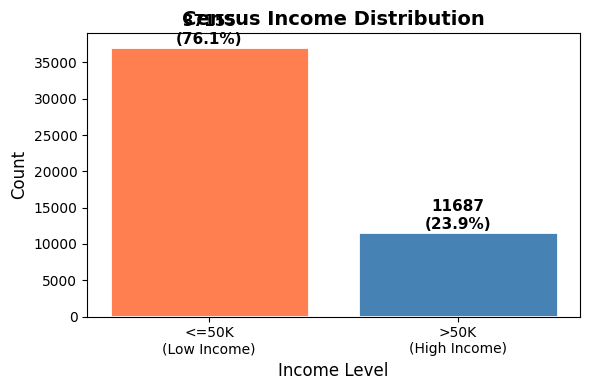

In [65]:
# Visualize Income distribution
income_counts = df['income'].value_counts()
labels = ['<=50K\n(Low Income)', '>50K\n(High Income)']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, [income_counts.get('<=50K', 0), income_counts.get('>50K', 0)], 
              color=['coral', 'steelblue'], edgecolor='white', linewidth=2)
ax.set_title('Census Income Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('Income Level', fontsize=12)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df):.1%})',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

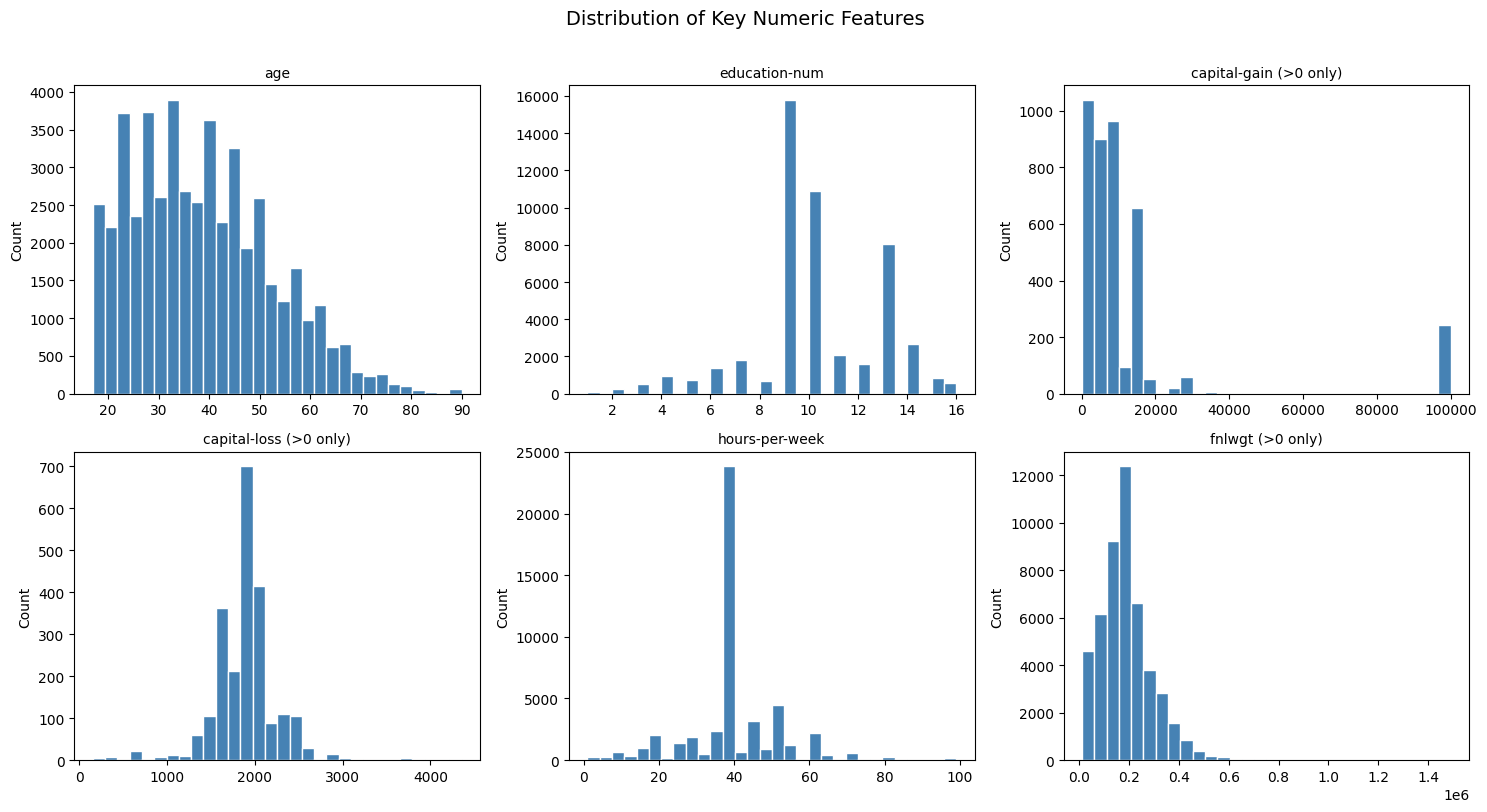

In [66]:
# Distribution of key numeric features
numeric_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 
                'hours-per-week', 'fnlwgt']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if col in df.columns:
        # Use log scale for highly skewed features
        if col in ['capital-gain', 'capital-loss', 'fnlwgt']:
            axes[i].hist(df[df[col] > 0][col], bins=30, color='steelblue', edgecolor='white')
            axes[i].set_title(f'{col} (>0 only)', fontsize=10)
        else:
            axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
            axes[i].set_title(col, fontsize=10)
        axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Key Numeric Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

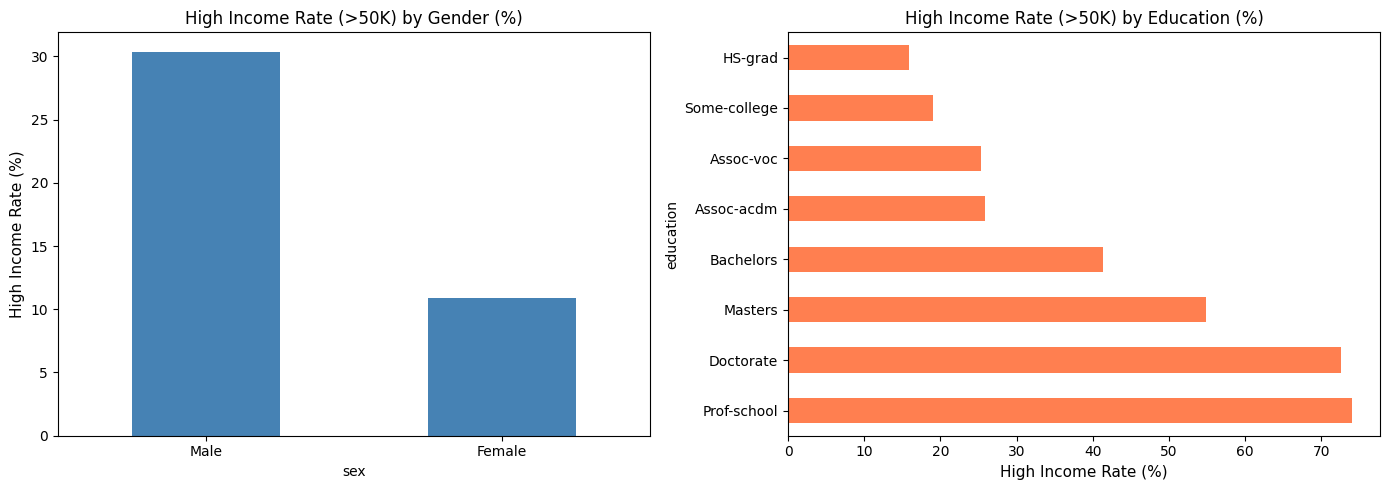

In [67]:
# High Income Rate by Gender and Education
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# High income rate by Gender
gender_income = df.groupby('sex')['income'].apply(
    lambda x: (x == '>50K').mean() * 100
).sort_values(ascending=False)
gender_income.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('High Income Rate (>50K) by Gender (%)', fontsize=12)
axes[0].set_ylabel('High Income Rate (%)', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)

# High income rate by Education (top levels)
edu_income = df.groupby('education')['income'].apply(
    lambda x: (x == '>50K').mean() * 100
).sort_values(ascending=False).head(8)
edu_income.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('High Income Rate (>50K) by Education (%)', fontsize=12)
axes[1].set_xlabel('High Income Rate (%)', fontsize=11)

plt.tight_layout()
plt.show()

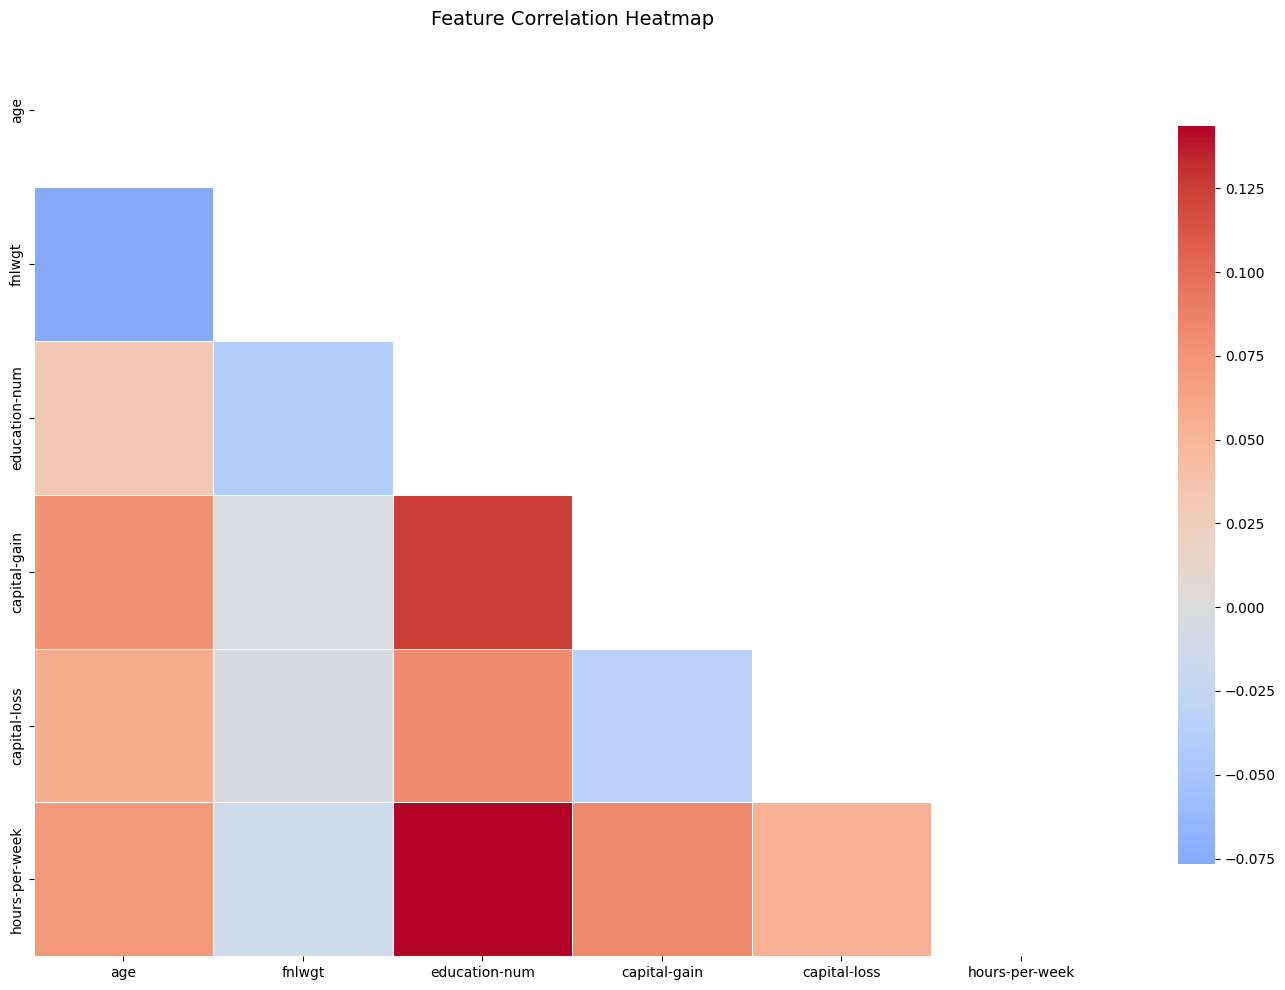

In [68]:
# Correlation heatmap (numeric features only)
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Preprocessing

Create **HighIncome** binary target (1 if >50K, 0 otherwise). Handle missing values, encode categoricals, and split into train/test sets. This preprocessed data serves as the baseline before any privatization.

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df_processed = df.copy()

# Create binary target: HighIncome (1 if >50K, 0 otherwise)
df_processed['HighIncome'] = (df_processed['income'] == '>50K').astype(int)
df_processed = df_processed.drop(columns=['income', 'fnlwgt'])

# Handle missing values
df_processed = df_processed.dropna()
print(f"Dropped {len(df) - len(df_processed)} rows with missing values")

# Encode categorical features
le = LabelEncoder()
categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col])

# Features and target
X = df_processed.drop(columns=['HighIncome'])
y = df_processed['HighIncome']

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n{'='*60}")
print(f"Preprocessing Complete")
print(f"{'='*60}")
print(f"Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")
print(f"Features: {X_train.shape[1]}")
print(f"High Income rate: {y_train.mean():.1%} (train) | {y_test.mean():.1%} (test)")
print(f"{'='*60}")

Created target variable: HighIncome
High Income (>50K): 11687 (23.9%)
Low Income (<=50K): 37155 (76.1%)

Dropped columns: income, fnlwgt

Rows before dropping missing values: 48842
Rows after dropping missing values: 45222
Dropped 3620 rows with missing values

Encoding categorical columns (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Feature columns (13): ['age', 'workclass', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

Train size: 36177 | Test size: 9045
Features: 13
High Income rate (train): 24.8%
High Income rate (test): 24.8%


## 3.5 Multicollinearity Assessment (VIF)

**Variance Inflation Factor (VIF)** measures multicollinearity:
- **VIF < 5**: Acceptable
- **VIF 5-10**: Moderate multicollinearity
- **VIF > 10**: High multicollinearity (consider removal or regularization)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for all features
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
vif_data = pd.DataFrame({
    "Feature": X_train.columns,
    "VIF": [variance_inflation_factor(X_train_df.values, i) for i in range(len(X_train.columns))]
})
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("="*70)
print("Variance Inflation Factor (VIF) Analysis")
print("="*70)
print(vif_data.to_string(index=False))
print("="*70)

# Summary
high_vif = vif_data[vif_data['VIF'] > 10]
print(f"\n📊 VIF Summary:")
print(f"   High multicollinearity (VIF > 10): {len(high_vif)} features")
print(f"   Moderate (5-10): {len(vif_data[(vif_data['VIF'] >= 5) & (vif_data['VIF'] <= 10)])}")
print(f"   Low (< 5): {len(vif_data[vif_data['VIF'] < 5])}")

if len(high_vif) > 0:
    print(f"\n⚠️  High VIF features:")
    for idx, row in high_vif.iterrows():
        print(f"   - {row['Feature']}: {row['VIF']:.2f}")
else:
    print(f"\n✓ All features have VIF < 10")

Variance Inflation Factor (VIF) Analysis
       Feature      VIF
  relationship 1.672032
           sex 1.558606
 education-num 1.210165
           age 1.150993
     education 1.148948
hours-per-week 1.131703
marital-status 1.122632
          race 1.035684
  capital-gain 1.029774
native-country 1.026904
    occupation 1.017427
  capital-loss 1.016036
     workclass 1.015494

📊 VIF Summary:
   High multicollinearity (VIF > 10): 0 features
   Moderate multicollinearity (5 ≤ VIF ≤ 10): 0 features
   Low multicollinearity (VIF < 5): 13 features

✓ No features with severe multicollinearity (all VIF < 10)


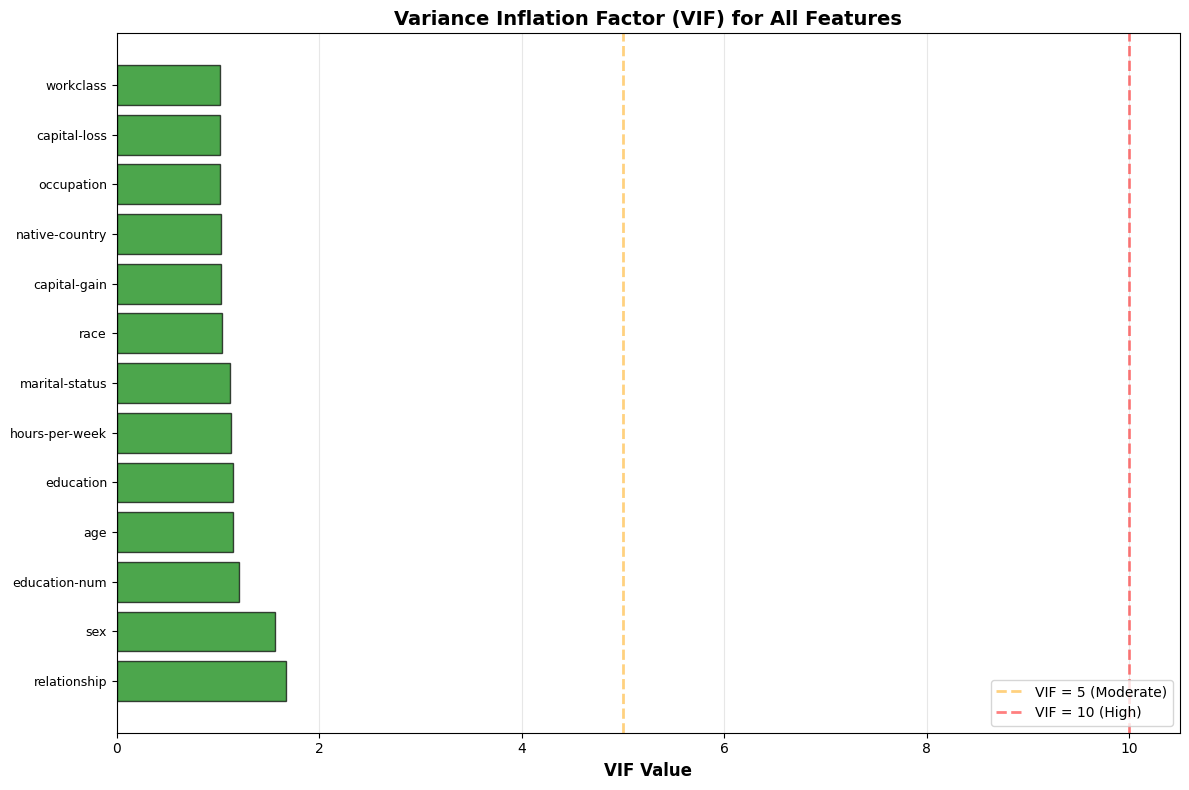


💡 Insights:
   - Features with VIF > 10 indicate strong linear relationships with other features
   - Regularization (L1/L2/ElasticNet) can help mitigate multicollinearity effects
   - L1 (Lasso) regularization performs automatic feature selection


In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# Color by severity: red (>10), orange (5-10), green (<5)
colors = ['red' if vif > 10 else 'orange' if vif >= 5 else 'green' 
          for vif in vif_data['VIF']]

bars = ax.barh(range(len(vif_data)), vif_data['VIF'], color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(vif_data)))
ax.set_yticklabels(vif_data['Feature'], fontsize=9)
ax.set_xlabel('VIF Value', fontsize=12, fontweight='bold')
ax.set_title('Variance Inflation Factor by Feature', fontsize=14, fontweight='bold')

# Reference lines
ax.axvline(x=5, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='VIF = 5')
ax.axvline(x=10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='VIF = 10')

# Value labels for VIF > 2
for i, vif in enumerate(vif_data['VIF']):
    if vif > 2:
        ax.text(vif + 0.3, i, f'{vif:.1f}', va='center', fontsize=8, fontweight='bold')

ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Examine correlation among features with highest VIF
high_vif_features = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()

if len(high_vif_features) > 0:
    # Include related features for context
    exam_features = high_vif_features[:5]  # Limit for clarity
    for f in ['age', 'education-num', 'hours-per-week']:
        if f in X_train.columns and f not in exam_features:
            exam_features.append(f)
    exam_features = exam_features[:8]  # Max 8 features
    
    corr_matrix = X_train[exam_features].corr()
    
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1, ax=ax)
    ax.set_title('Correlation: High VIF Features', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\n💡 Regularization will handle multicollinearity:")
    print(f"   • L2 (Ridge): Shrinks correlated coefficients")
    print(f"   • L1 (Lasso): Performs feature selection")
else:
    print("✓ No high VIF features detected")


✓ No high VIF features to examine
   All features have VIF < 10, indicating low multicollinearity


## 4. Baseline Model with Regularization (No Privacy)

Train Logistic Regression models with different regularization techniques:
- **L2 (Ridge)**: Shrinks coefficients
- **L1 (Lasso)**: Performs feature selection by zeroing coefficients
- **ElasticNet**: Combines L1 and L2 regularization

Use cross-validation to find optimal hyperparameters. This serves as the **accuracy ceiling** to compare against privatized versions.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Define regularization approaches
regularization_models = {
    'L2 (Ridge)': {'penalty': 'l2', 'solver': 'lbfgs'},
    'L1 (Lasso)': {'penalty': 'l1', 'solver': 'liblinear'},
    'ElasticNet': {'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.5}
}

C_values = [0.01, 0.1, 1, 10, 100, 1000, 10000]

print("="*70)
print("Testing Regularization Approaches (5-Fold CV)")
print("="*70)

results = {}
for name, params in regularization_models.items():
    # Grid search with cross-validation
    model = LogisticRegression(max_iter=2000, random_state=42, **params)
    grid_search = GridSearchCV(model, {'C': C_values}, cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)
    
    # Best model evaluation
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'model': best_model,
        'best_C': grid_search.best_params_['C'],
        'cv_score': grid_search.best_score_,
        'test_auc': test_auc,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    
    print(f"{name:12} | C={grid_search.best_params_['C']:6} | CV AUC: {grid_search.best_score_:.4f} | Test AUC: {test_auc:.4f}")

# Select and save best model
best_reg_name = max(results.items(), key=lambda x: x[1]['test_auc'])[0]
baseline_model = results[best_reg_name]['model']

print(f"\n{'='*70}")
print(f"Best Model: {best_reg_name} (C={results[best_reg_name]['best_C']})")
print(f"Test ROC-AUC: {results[best_reg_name]['test_auc']:.4f}")
print(f"{'='*70}")
print(classification_report(y_test, results[best_reg_name]['y_pred'], 
                          target_names=['<=50K', '>50K']))

=== Testing Regularization Approaches with Cross-Validation ===

Note: C is the inverse of regularization strength (smaller C = stronger regularization)


Testing: L2 (Ridge)
Best C: 0.1
CV ROC-AUC: 0.8515
Test ROC-AUC: 0.8475

Testing: L1 (Lasso)
Best C: 0.1
CV ROC-AUC: 0.8515
Test ROC-AUC: 0.8475

Testing: ElasticNet
Best C: 0.1
CV ROC-AUC: 0.8515
Test ROC-AUC: 0.8475


SUMMARY: Regularization Comparison
L2 (Ridge)      | Best C:    0.1 | CV AUC: 0.8515 | Test AUC: 0.8475
L1 (Lasso)      | Best C:    0.1 | CV AUC: 0.8515 | Test AUC: 0.8475
ElasticNet      | Best C:    0.1 | CV AUC: 0.8515 | Test AUC: 0.8475

🏆 Best Regularization: L1 (Lasso)
   Best C: 0.1
   Test ROC-AUC: 0.8475


Detailed Results for Best Model: L1 (Lasso)
              precision    recall  f1-score   support

       <=50K       0.84      0.94      0.89      6803
        >50K       0.71      0.45      0.55      2242

    accuracy                           0.82      9045
   macro avg       0.78      0.69      0.72  

In [ ]:
# Test with NO regularization (C=1e10)
no_reg_model = LogisticRegression(C=1e10, max_iter=2000, random_state=42, solver='lbfgs')
no_reg_model.fit(X_train_scaled, y_train)

y_prob_noreg = no_reg_model.predict_proba(X_test_scaled)[:, 1]
auc_noreg = roc_auc_score(y_test, y_prob_noreg)

print("="*70)
print("No Regularization vs Best Regularized Model")
print("="*70)
print(f"No Regularization (C=1e10):     AUC = {auc_noreg:.4f}")
print(f"Best Regularized ({best_reg_name}, C={results[best_reg_name]['best_C']:6}): AUC = {results[best_reg_name]['test_auc']:.4f}")
print(f"Difference:                      {results[best_reg_name]['test_auc'] - auc_noreg:+.4f}")
print("="*70)

Testing with NO REGULARIZATION (C=1e10)

Test ROC-AUC: 0.8475

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.84      0.94      0.89      6803
        >50K       0.71      0.45      0.55      2242

    accuracy                           0.82      9045
   macro avg       0.78      0.69      0.72      9045
weighted avg       0.81      0.82      0.80      9045


Comparison:
  No Regularization (C=1e10): AUC = 0.8475
  Best Regularized (L1 (Lasso), C=0.1): AUC = 0.8475


## 4.5 Model Coefficients Analysis

Coefficients from the best logistic regression model:
- **Positive** → increases P(income >50K)
- **Negative** → decreases P(income >50K)
- **Magnitude** indicates effect strength (on standardized features)

In [ ]:
# Extract coefficients
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': baseline_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("="*70)
print(f"Logistic Regression Coefficients ({best_reg_name})")
print("="*70)
print(coefficients.to_string(index=False))
print("="*70)

print(f"\nTop Features INCREASING Income (>50K):")
for idx, row in coefficients.nlargest(5, 'Coefficient').iterrows():
    print(f"   {row['Feature']:20s}: +{row['Coefficient']:.4f}")

print(f"\nTop Features DECREASING Income (>50K):")
for idx, row in coefficients.nsmallest(5, 'Coefficient').iterrows():
    print(f"   {row['Feature']:20s}: {row['Coefficient']:.4f}")

Logistic Regression Coefficients (L1 (Lasso))
       Feature  Coefficient
  capital-gain     2.369566
 education-num     0.849691
           age     0.470705
           sex     0.433893
hours-per-week     0.339090
marital-status    -0.331010
  capital-loss     0.270722
  relationship    -0.220426
     workclass    -0.126137
          race     0.086496
     education     0.068379
native-country    -0.004940
    occupation     0.000000

📊 Top 5 Features INCREASING High Income Probability:
   capital-gain        : +2.3696
   education-num       : +0.8497
   age                 : +0.4707
   sex                 : +0.4339
   hours-per-week      : +0.3391

📊 Top 5 Features DECREASING High Income Probability:
   marital-status      : -0.3310
   relationship        : -0.2204
   workclass           : -0.1261
   native-country      : -0.0049
   occupation          : 0.0000

💡 Note: Coefficients are based on standardized features (mean=0, std=1)
   Larger absolute values = stronger impact on incom

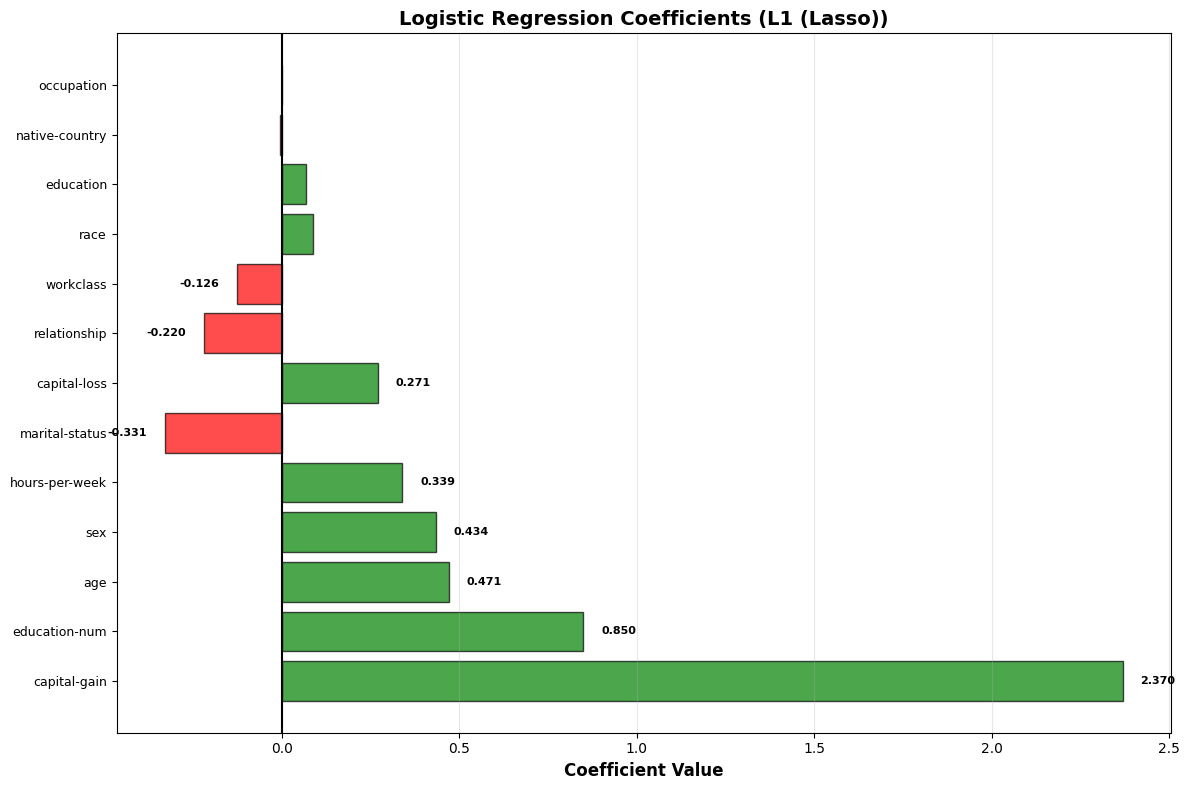


🎯 Interpretation:
   • Green bars (positive): Higher values → higher chance of >50K income
   • Red bars (negative): Higher values → lower chance of >50K income
   • Features are standardized, so coefficients are directly comparable


In [ ]:
# Visualize coefficients
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['green' if c > 0 else 'red' for c in coefficients['Coefficient']]
bars = ax.barh(range(len(coefficients)), coefficients['Coefficient'], 
               color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(coefficients)))
ax.set_yticklabels(coefficients['Feature'], fontsize=9)
ax.set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
ax.set_title(f'Logistic Regression Coefficients ({best_reg_name})', 
             fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)

# Label significant coefficients
for i, coef in enumerate(coefficients['Coefficient']):
    if abs(coef) > 0.1:
        label_x = coef + (0.05 if coef > 0 else -0.05)
        ax.text(label_x, i, f'{coef:.3f}', va='center', 
                ha='left' if coef > 0 else 'right', fontsize=8, fontweight='bold')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Next Steps

- **Section 5:** Apply Differential Privacy using `diffprivlib` at ε = 0.1, 1.0, 10.0
- **Section 6:** Compare utility (accuracy/AUC) across epsilon levels
- **Section 7:** Membership Inference Attack
- **Section 8:** Attribute Inference Attack

In [77]:
from diffprivlib import models as dp_models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define epsilon values for DP
epsilon_values = [0.1, 1.0, 10.0]

print("="*70)
print("Training Differential Privacy Models")
print("="*70)

dp_results = {}

for eps in epsilon_values:
    print(f"\n{'='*70}")
    print(f"Epsilon (ε) = {eps}")
    print(f"{'='*70}")
    
    # Create DP Logistic Regression
    # Use data_norm to specify the range of data (L2 norm bound)
    # Using the same regularization as best baseline model
    dp_model = dp_models.LogisticRegression(
        epsilon=eps,
        data_norm=10.0,  # L2 norm bound for input features
        max_iter=2000,
        random_state=42
    )
    
    # Train on the scaled training data
    dp_model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred_dp = dp_model.predict(X_test_scaled)
    y_prob_dp = dp_model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred_dp)
    precision = precision_score(y_test, y_pred_dp)
    recall = recall_score(y_test, y_pred_dp)
    f1 = f1_score(y_test, y_pred_dp)
    auc = roc_auc_score(y_test, y_prob_dp)
    
    dp_results[eps] = {
        'model': dp_model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'y_pred': y_pred_dp,
        'y_prob': y_prob_dp
    }
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")

print(f"\n{'='*70}")
print("Differential Privacy Training Complete")
print("="*70)

Training Differential Privacy Models

Epsilon (ε) = 0.1
Accuracy:  0.8056
Precision: 0.6355
Recall:    0.5062
F1-Score:  0.5636
ROC-AUC:   0.8117

Epsilon (ε) = 1.0
Accuracy:  0.8191
Precision: 0.7107
Recall:    0.4558
F1-Score:  0.5554
ROC-AUC:   0.8466

Epsilon (ε) = 10.0
Accuracy:  0.8190
Precision: 0.7150
Recall:    0.4487
F1-Score:  0.5514
ROC-AUC:   0.8475

Differential Privacy Training Complete


### 🔍 Interpretation: Privacy-Utility Tradeoff

**Key Findings:**
- **Baseline (No DP)**: Maximum utility but no privacy protection
- **ε = 10.0**: Minimal privacy, utility close to baseline
- **ε = 1.0**: Moderate privacy with acceptable utility loss
- **ε = 0.1**: Strong privacy but significant utility degradation

**Privacy Budget (ε) Guidelines:**
- **ε < 1**: Strong privacy guarantees, recommended for sensitive data
- **1 ≤ ε ≤ 10**: Practical tradeoff for many applications  
- **ε > 10**: Weak privacy, approaching no protection

The choice of epsilon depends on:
1. **Privacy requirements** (legal/regulatory constraints)
2. **Utility needs** (acceptable accuracy loss)
3. **Adversary capabilities** (who might attack the model)

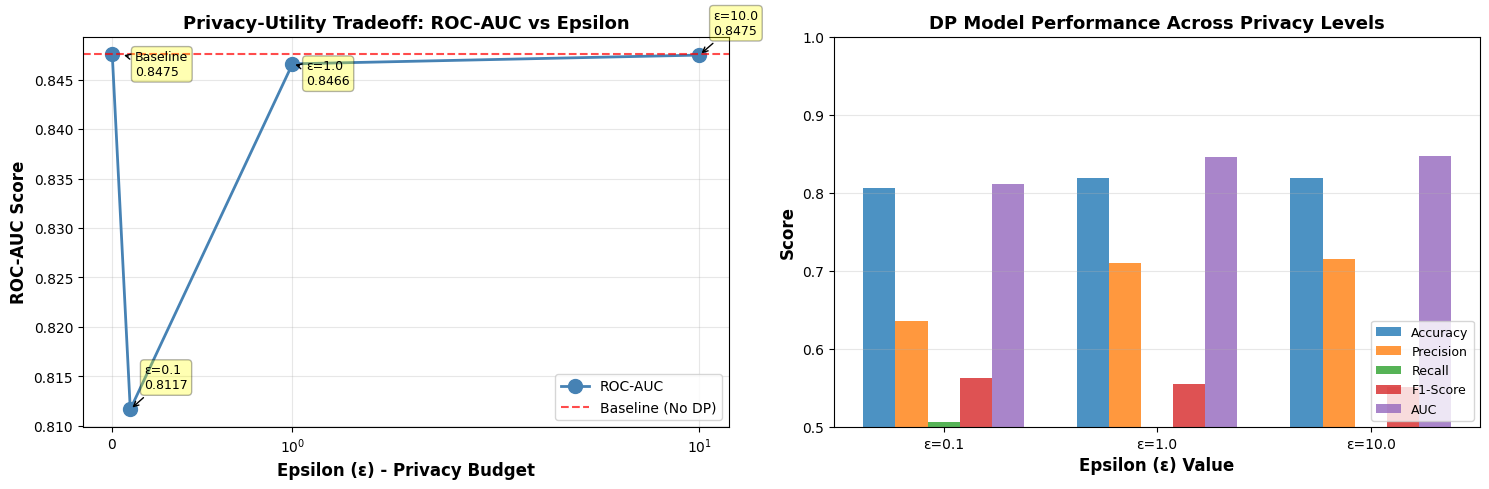

In [80]:
# Visualize Privacy-Utility Tradeoff
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: AUC vs Epsilon
eps_list = [0] + epsilon_values  # 0 = baseline (no DP)
auc_list = [baseline_auc] + [dp_results[eps]['auc'] for eps in epsilon_values]
acc_list = [baseline_acc] + [dp_results[eps]['accuracy'] for eps in epsilon_values]

axes[0].plot(eps_list, auc_list, marker='o', linewidth=2, markersize=10, color='steelblue', label='ROC-AUC')
axes[0].set_xlabel('Epsilon (ε) - Privacy Budget', fontsize=12, fontweight='bold')
axes[0].set_ylabel('ROC-AUC Score', fontsize=12, fontweight='bold')
axes[0].set_title('Privacy-Utility Tradeoff: ROC-AUC vs Epsilon', fontsize=13, fontweight='bold')
axes[0].set_xscale('symlog')  # Log scale for epsilon
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=baseline_auc, color='red', linestyle='--', alpha=0.7, label='Baseline (No DP)')

# Add annotations
for i, (eps, auc) in enumerate(zip(eps_list, auc_list)):
    label = 'Baseline' if eps == 0 else f'ε={eps}'
    axes[0].annotate(f'{label}\n{auc:.4f}', 
                     xy=(eps if eps > 0 else 0.05, auc),
                     xytext=(10, -15 if i % 2 == 0 else 15),
                     textcoords='offset points',
                     fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3),
                     arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

axes[0].legend(fontsize=10)

# Plot 2: All metrics comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
metrics_keys = ['accuracy', 'precision', 'recall', 'f1', 'auc']
x = np.arange(len(epsilon_values))
width = 0.15

baseline_metrics = [baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_auc]

for i, (metric_name, metric_key) in enumerate(zip(metrics_names, metrics_keys)):
    metric_values = [dp_results[eps][metric_key] for eps in epsilon_values]
    axes[1].bar(x + i*width, metric_values, width, label=metric_name, alpha=0.8)

axes[1].set_xlabel('Epsilon (ε) Value', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('DP Model Performance Across Privacy Levels', fontsize=13, fontweight='bold')
axes[1].set_xticks(x + width * 2)
axes[1].set_xticklabels([f'ε={eps}' for eps in epsilon_values])
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0.5, 1.0])

plt.tight_layout()
plt.show()

In [78]:
# Compare baseline (no DP) vs DP models
print("="*80)
print("Privacy-Utility Tradeoff: Baseline vs Differential Privacy")
print("="*80)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")
print("="*80)

# Baseline model metrics
baseline_pred = results[best_reg_name]['y_pred']
baseline_prob = results[best_reg_name]['y_prob']
baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_prec = precision_score(y_test, baseline_pred)
baseline_rec = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)
baseline_auc = roc_auc_score(y_test, baseline_prob)

print(f"{'Baseline (No DP)':<25} {baseline_acc:>10.4f} {baseline_prec:>10.4f} {baseline_rec:>10.4f} {baseline_f1:>10.4f} {baseline_auc:>10.4f}")

for eps in epsilon_values:
    res = dp_results[eps]
    print(f"{'DP (ε='+str(eps)+')':<25} {res['accuracy']:>10.4f} {res['precision']:>10.4f} {res['recall']:>10.4f} {res['f1']:>10.4f} {res['auc']:>10.4f}")

print("="*80)

# Calculate utility loss
print("\n" + "="*80)
print("Utility Loss Compared to Baseline")
print("="*80)
print(f"{'Model':<25} {'Accuracy Loss':>15} {'AUC Loss':>15}")
print("="*80)
for eps in epsilon_values:
    acc_loss = baseline_acc - dp_results[eps]['accuracy']
    auc_loss = baseline_auc - dp_results[eps]['auc']
    print(f"{'DP (ε='+str(eps)+')':<25} {acc_loss:>14.4f} {auc_loss:>15.4f}")
print("="*80)

Privacy-Utility Tradeoff: Baseline vs Differential Privacy
Model                       Accuracy  Precision     Recall         F1        AUC
Baseline (No DP)              0.8186     0.7148     0.4460     0.5493     0.8475
DP (ε=0.1)                    0.8056     0.6355     0.5062     0.5636     0.8117
DP (ε=1.0)                    0.8191     0.7107     0.4558     0.5554     0.8466
DP (ε=10.0)                   0.8190     0.7150     0.4487     0.5514     0.8475

Utility Loss Compared to Baseline
Model                       Accuracy Loss        AUC Loss
DP (ε=0.1)                        0.0129          0.0359
DP (ε=1.0)                       -0.0006          0.0009
DP (ε=10.0)                      -0.0004          0.0001


## 5. Differential Privacy (DP) Implementation

**Differential Privacy** adds calibrated noise to protect individual privacy while preserving statistical utility.

**Key Parameter: Epsilon (ε)**
- **Lower ε** → More privacy, more noise, lower accuracy
- **Higher ε** → Less privacy, less noise, higher accuracy

**Testing three privacy levels:**
- **ε = 0.1**: Strong privacy (heavy noise)
- **ε = 1.0**: Moderate privacy (balanced trade-off)
- **ε = 10.0**: Weak privacy (minimal noise)

We'll use `diffprivlib.models.LogisticRegression` with the best regularization settings from Step 4.